In [5]:
import pandas as pd
import numpy as np
import re
import os
import warnings
warnings.filterwarnings("ignore")
print("libraries imported")

libraries imported


In [15]:

print("=" * 60)
print("  PHASE 1 — DATA SETUP & CLEANING")
print("=" * 60)

# Dataset paths
train_path = r"C:\Users\Akash\OneDrive\Documents\OneDrive\Desktop\data analyat pr\Fake News Dataset\Fake News Dataset\train.csv"
test_path = r"C:\Users\Akash\OneDrive\Documents\OneDrive\Desktop\data analyat pr\Fake News Dataset\Fake News Dataset\test.csv"

# Verify files exist
for f in [train_path, test_path]:
    if not os.path.exists(f):
        raise FileNotFoundError(
            f"❌ File not found: {f} — place it in the same directory as this script."
        )

# Load datasets
df_train = pd.read_csv(train_path, sep=";")
df_test = pd.read_csv(test_path, sep=";")

print(f"\n✅ Training rows : {len(df_train):,}")
print(f"✅ Testing rows  : {len(df_test):,}")

print("\nColumns:")
print(df_train.columns.tolist())

print("\nFirst 5 rows:")
print(df_train.head())

# Check if label column exists
if "label" in df_train.columns:
    print("\nLabel Distribution (Train):")
    print(df_train["label"].value_counts())
else:
    print("\n❌ 'label' column not found.")
    print("Available columns:", df_train.columns.tolist())

  PHASE 1 — DATA SETUP & CLEANING

✅ Training rows : 16,646
✅ Testing rows  : 4,035

Columns:
['text', 'label']

First 5 rows:
                                                text  label
0  dark agenda behind globalism open border altma...      0
1  america poor still get shaft sami jamil jadall...      0
2  number accuser grow former miss finland accuse...      0
3  heroic prego advertisement replaces refresh we...      0
4  russia syria debbie reynolds thursday even bri...      1

Label Distribution (Train):
label
0    8323
1    8323
Name: count, dtype: int64


In [16]:
print("\n" + "─" * 60)
print("STEP 1 — BASIC INSPECTION")
print("─" * 60)
 
print("\n▶ First 3 rows:")
print(df.head(3).to_string())
 
print("\n▶ Dataset info:")
df.info()
 
print("\n▶ Label distribution:")
counts = df["label"].value_counts()
print(f"    REAL  (0) : {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)")
print(f"    FAKE  (1) : {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)")


────────────────────────────────────────────────────────────
STEP 1 — BASIC INSPECTION
────────────────────────────────────────────────────────────

▶ First 3 rows:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [17]:
print("\n" + "─" * 60)
print("STEP 2 — NULL VALUES")
print("─" * 60)
 
null_counts = df.isnull().sum()
print(f"\nNull counts per column:\n{null_counts}")
 
before = len(df)
df.dropna(inplace=True)
after = len(df)
print(f"\n✅  Dropped {before - after} rows with nulls. Remaining: {after:,}")


────────────────────────────────────────────────────────────
STEP 2 — NULL VALUES
────────────────────────────────────────────────────────────

Null counts per column:
text     0
label    0
dtype: int64

✅  Dropped 0 rows with nulls. Remaining: 16,646


In [18]:
print("\n" + "─" * 60)
print("STEP 3 — DUPLICATES")
print("─" * 60)
 
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"✅  Dropped {before - after} duplicate rows. Remaining: {after:,}")


────────────────────────────────────────────────────────────
STEP 3 — DUPLICATES
────────────────────────────────────────────────────────────
✅  Dropped 171 duplicate rows. Remaining: 16,475


In [19]:
print("\n" + "─" * 60)
print("STEP 4 — TEXT COLUMN PREPARATION")
print("─" * 60)
 
# Combine title + text for richer features (drop if 'title' column absent)
if "title" in df.columns and "text" in df.columns:
    df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")
    print("✅  Combined 'title' + 'text' → 'content' column")
elif "text" in df.columns:
    df["content"] = df["text"].fillna("")
    print("✅  Using 'text' column as 'content'")
else:
    # Fallback: use whichever string column exists
    str_cols = df.select_dtypes(include="object").columns.tolist()
    df["content"] = df[str_cols[0]].fillna("")
    print(f"✅  Using '{str_cols[0]}' as content column")


────────────────────────────────────────────────────────────
STEP 4 — TEXT COLUMN PREPARATION
────────────────────────────────────────────────────────────
✅  Using 'text' column as 'content'


In [20]:
print("\n" + "─" * 60)
print("STEP 5 — TEXT CLEANING")
print("─" * 60)
 
def clean_text(text: str) -> str:
    """
    Applies the following cleaning steps:
      1. Convert to lowercase
      2. Remove URLs
      3. Remove HTML tags
      4. Remove special characters & digits
      5. Collapse extra whitespace
    """
    text = str(text).lower()                            # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)          # remove URLs
    text = re.sub(r"<.*?>", "", text)                   # remove HTML tags
    text = re.sub(r"[^a-z\s]", "", text)                # keep only letters
    text = re.sub(r"\s+", " ", text).strip()            # collapse spaces
    return text
 
df["content_clean"] = df["content"].apply(clean_text)
 
print("✅  Text cleaning applied. Sample comparison:")
sample_idx = df.index[0]
print(f"\n  BEFORE: {df.loc[sample_idx, 'content'][:120]}...")
print(f"\n  AFTER : {df.loc[sample_idx, 'content_clean'][:120]}...")


────────────────────────────────────────────────────────────
STEP 5 — TEXT CLEANING
────────────────────────────────────────────────────────────
✅  Text cleaning applied. Sample comparison:

  BEFORE: dark agenda behind globalism open border altmarket brandon smith people unfamiliar liberty movement stumble onto undenia...

  AFTER : dark agenda behind globalism open border altmarket brandon smith people unfamiliar liberty movement stumble onto undenia...


In [21]:
df["word_count"] = df["content_clean"].apply(lambda x: len(x.split()))
 
print(f"\n▶ Word count stats:")
print(df["word_count"].describe().round(1).to_string())


▶ Word count stats:
count    16475.0
mean       427.0
std        443.6
min          1.0
25%        161.0
50%        319.0
75%        587.0
max      10209.0


In [22]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\n✅  Dataset shuffled (random_state=42)")
 
# ── 13. KEEP ONLY NEEDED COLUMNS ────────────────────────────
df_clean = df[["content_clean", "label", "word_count"]].copy()
df_clean.rename(columns={"content_clean": "text"}, inplace=True)
 
print(f"\n✅  Final cleaned dataset shape: {df_clean.shape}")
print(f"\n▶ Final dataframe preview:")
print(df_clean.head(5).to_string())


✅  Dataset shuffled (random_state=42)

✅  Final cleaned dataset shape: (16475, 3)

▶ Final dataframe preview:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [23]:
output_path = "cleaned_news.csv"
df_clean.to_csv(output_path, index=False)
print(f"\n💾  Cleaned dataset saved to → {output_path}")


💾  Cleaned dataset saved to → cleaned_news.csv


In [24]:
print("\n" + "=" * 60)
print("  PHASE 1 COMPLETE — SUMMARY")
print("=" * 60)
print(f"  Total articles  : {len(df_clean):,}")
print(f"  Fake (label=1)  : {(df_clean.label==1).sum():,}")
print(f"  Real (label=0)  : {(df_clean.label==0).sum():,}")
print(f"  Avg word count  : {df_clean.word_count.mean():.0f} words")
print(f"  Output file     : {output_path}")
print(f"\n  ✅  Ready for Phase 2 — Text Preprocessing & TF-IDF")
print("=" * 60)


  PHASE 1 COMPLETE — SUMMARY
  Total articles  : 16,475
  Fake (label=1)  : 8,323
  Real (label=0)  : 8,152
  Avg word count  : 427 words
  Output file     : cleaned_news.csv

  ✅  Ready for Phase 2 — Text Preprocessing & TF-IDF


In [25]:
import pandas as pd
import numpy as np
import nltk
import pickle
import warnings

warnings.filterwarnings("ignore")

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer

In [27]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Akash\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Akash\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [28]:
print("=" * 60)
print("  PHASE 2 — TEXT PREPROCESSING & TF-IDF")
print("=" * 60)

input_file = "cleaned_news.csv"

df = pd.read_csv(input_file)

print(f"\n✅ Dataset Loaded Successfully")
print(f"📦 Shape : {df.shape}")

  PHASE 2 — TEXT PREPROCESSING & TF-IDF

✅ Dataset Loaded Successfully
📦 Shape : (16475, 3)


In [30]:
required_cols = ["text", "label"]

for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"❌ Missing required column: {col}")

print("\n✅ Required columns verified")


✅ Required columns verified


In [43]:
print("\n" + "─" * 60)
print("STEP 1 — TOKENIZATION")
print("─" * 60)

df["tokens"] = df["text"].apply(
    lambda x: word_tokenize(str(x))
)

print("✅ Tokenization completed")

print("\nSample Tokens:")
print(df["tokens"].iloc[0][:50])


────────────────────────────────────────────────────────────
STEP 1 — TOKENIZATION
────────────────────────────────────────────────────────────
✅ Tokenization completed

Sample Tokens:
['trump', 'hometown', 'clear', 'message', 'defiance', 'woman', 'new', 'york', 'time', 'new', 'yorkers', 'flood', 'street', 'manhattan', 'saturday', 'aim', 'send', 'message', 'president', 'trump', 'hometown', 'would', 'center', 'resistance', 'administration', 'mayor', 'office', 'estimate', 'people', 'take', 'part', 'march', 'concert', 'woman', 'march', 'rally', 'across', 'country', 'huge', 'crowd', 'along', 'fifth', 'avenue', 'near', 'trump', 'tower', 'large', 'slice', 'manhattan', 'come']


In [36]:
print("\n" + "─" * 60)
print("STEP 2 — STOPWORD REMOVAL")
print("─" * 60)

stop_words = set(stopwords.words("english"))

df["tokens_no_stopwords"] = df["tokens"].apply(
    lambda words: [
        word for word in words
        if word.lower() not in stop_words
    ]
)

print("✅ Stopwords removed")

print("\nSample:")
print(df["tokens_no_stopwords"].iloc[0][:20])


────────────────────────────────────────────────────────────
STEP 2 — STOPWORD REMOVAL
────────────────────────────────────────────────────────────
✅ Stopwords removed

Sample:
['trump', 'hometown', 'clear', 'message', 'defiance', 'woman', 'new', 'york', 'time', 'new', 'yorkers', 'flood', 'street', 'manhattan', 'saturday', 'aim', 'send', 'message', 'president', 'trump']


In [44]:


import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df["tokens_lemmatized"] = df["tokens_no_stopwords"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

print("✅ Lemmatization completed")

print("\nSample:")
print(df["tokens_lemmatized"].iloc[0][:20])

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Akash\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Akash\AppData\Roaming\nltk_data...


✅ Lemmatization completed

Sample:
['trump', 'hometown', 'clear', 'message', 'defiance', 'woman', 'new', 'york', 'time', 'new', 'yorkers', 'flood', 'street', 'manhattan', 'saturday', 'aim', 'send', 'message', 'president', 'trump']


In [49]:
print("\n" + "─" * 60)
print("STEP 4 — STEMMING")
print("─" * 60)

stemmer = PorterStemmer()

df["tokens_stemmed"] = df["tokens_no_stopwords"].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

print("✅ Stemming completed")

print("\nSample:")
print(df["tokens_stemmed"].iloc[0][:20])


────────────────────────────────────────────────────────────
STEP 4 — STEMMING
────────────────────────────────────────────────────────────
✅ Stemming completed

Sample:
['trump', 'hometown', 'clear', 'messag', 'defianc', 'woman', 'new', 'york', 'time', 'new', 'yorker', 'flood', 'street', 'manhattan', 'saturday', 'aim', 'send', 'messag', 'presid', 'trump']


In [48]:
print("\n" + "─" * 60)
print("STEP 5 — RECONSTRUCT CLEAN TEXT")
print("─" * 60)

df["processed_text"] = df["tokens_stemmed"].apply(
    lambda words: " ".join(words)
)

print("✅ Processed text created")

print("\nSample Processed Text:")
print(df["processed_text"].iloc[0][:200])


────────────────────────────────────────────────────────────
STEP 5 — RECONSTRUCT CLEAN TEXT
────────────────────────────────────────────────────────────
✅ Processed text created

Sample Processed Text:
trump hometown clear messag defianc woman new york time new yorker flood street manhattan saturday aim send messag presid trump hometown would center resist administr mayor offic estim peopl take part


In [47]:
print("\n" + "─" * 60)
print("STEP 6 — TF-IDF FEATURE EXTRACTION")
print("─" * 60)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df["processed_text"])

y = df["label"]

print("✅ TF-IDF completed")

print(f"\nFeature Matrix Shape : {X.shape}")
print(f"Labels Shape         : {y.shape}")


────────────────────────────────────────────────────────────
STEP 6 — TF-IDF FEATURE EXTRACTION
────────────────────────────────────────────────────────────
✅ TF-IDF completed

Feature Matrix Shape : (16475, 5000)
Labels Shape         : (16475,)


In [46]:
print("\n" + "─" * 60)
print("STEP 7 — TOP VOCABULARY FEATURES")
print("─" * 60)

features = tfidf.get_feature_names_out()

print(f"\nTotal Vocabulary Size: {len(features):,}")

print("\nFirst 30 Features:")
print(features[:30])


────────────────────────────────────────────────────────────
STEP 7 — TOP VOCABULARY FEATURES
────────────────────────────────────────────────────────────

Total Vocabulary Size: 5,000

First 30 Features:
['aaron' 'abandon' 'abc' 'abe' 'abedin' 'abil' 'abl' 'abort' 'abroad'
 'absenc' 'absolut' 'absorb' 'absurd' 'abu' 'abus' 'academ' 'academi'
 'acceler' 'accept' 'access' 'access pipelin' 'accid' 'accident'
 'accommod' 'accompani' 'accomplish' 'accord' 'accord report' 'account'
 'accur']


In [45]:
print("\n" + "─" * 60)
print("STEP 8 — SAVE ARTIFACTS")
print("─" * 60)

with open("X_tfidf.pkl", "wb") as f:
    pickle.dump(X, f)

with open("y_labels.pkl", "wb") as f:
    pickle.dump(y, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("✅ Saved:")
print("   • X_tfidf.pkl")
print("   • y_labels.pkl")
print("   • tfidf_vectorizer.pkl")


────────────────────────────────────────────────────────────
STEP 8 — SAVE ARTIFACTS
────────────────────────────────────────────────────────────
✅ Saved:
   • X_tfidf.pkl
   • y_labels.pkl
   • tfidf_vectorizer.pkl


In [50]:
output_file = "preprocessed_news.csv"

df.to_csv(output_file, index=False)

print(f"\n💾 Preprocessed dataset saved → {output_file}")


💾 Preprocessed dataset saved → preprocessed_news.csv


In [51]:
print("\n" + "=" * 60)
print("  PHASE 2 COMPLETE — SUMMARY")
print("=" * 60)

print(f"Articles Processed : {len(df):,}")
print(f"Vocabulary Size    : {len(features):,}")
print(f"TF-IDF Features    : {X.shape[1]:,}")
print(f"Output Dataset     : {output_file}")

print("\n✅ Ready for Phase 3 — Train/Test Split & Model Training")
print("=" * 60)


  PHASE 2 COMPLETE — SUMMARY
Articles Processed : 16,475
Vocabulary Size    : 5,000
TF-IDF Features    : 5,000
Output Dataset     : preprocessed_news.csv

✅ Ready for Phase 3 — Train/Test Split & Model Training


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

plt.style.use('default')

In [53]:
print("=" * 60)
print("  PHASE 3 — EDA & VISUALIZATION")
print("=" * 60)

df = pd.read_csv("cleaned_news.csv")

print(df.head())
print(df.shape)

  PHASE 3 — EDA & VISUALIZATION
                                                text  label  word_count
0  trump hometown clear message defiance woman ne...      1         299
1  uber suspends test selfdriving vehicle arizona...      1         305
2  donald trump tell uk make kate bush new queen ...      0         107
3  baseball slow fix new york time major league b...      1        2673
4  roy moore u presidential race deepwater horizo...      1         468
(16475, 3)


In [54]:
print("\nDataset Info:")
print(df.info())

print("\nLabel Distribution:")
print(df["label"].value_counts())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 16475 entries, 0 to 16474
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        16475 non-null  str  
 1   label       16475 non-null  int64
 2   word_count  16475 non-null  int64
dtypes: int64(2), str(1)
memory usage: 386.3 KB
None

Label Distribution:
label
1    8323
0    8152
Name: count, dtype: int64


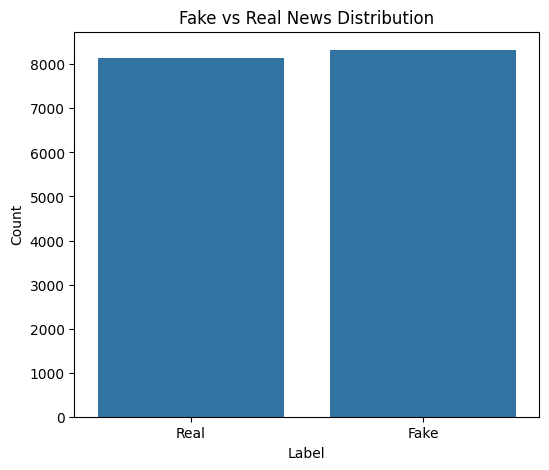

In [55]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="label",
    data=df
)

plt.title("Fake vs Real News Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.xticks(
    [0,1],
    ["Real","Fake"]
)

plt.show()

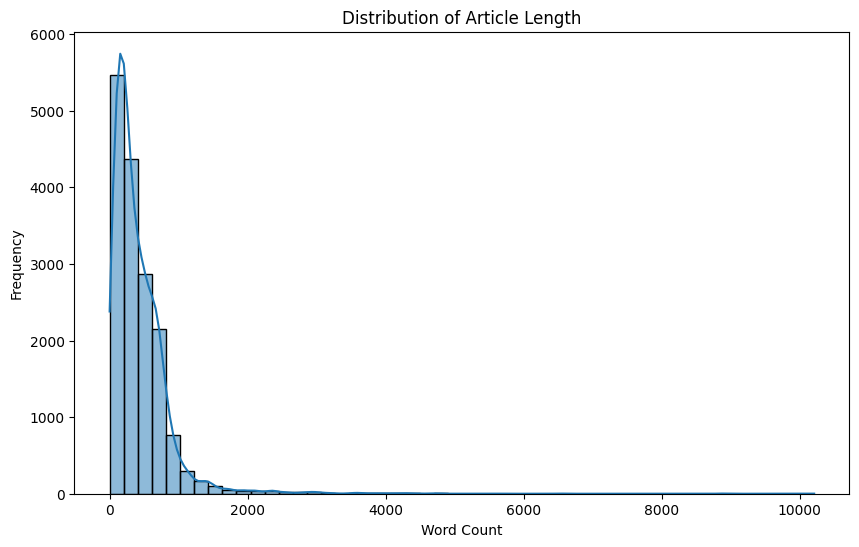

In [56]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="word_count",
    bins=50,
    kde=True
)

plt.title("Distribution of Article Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

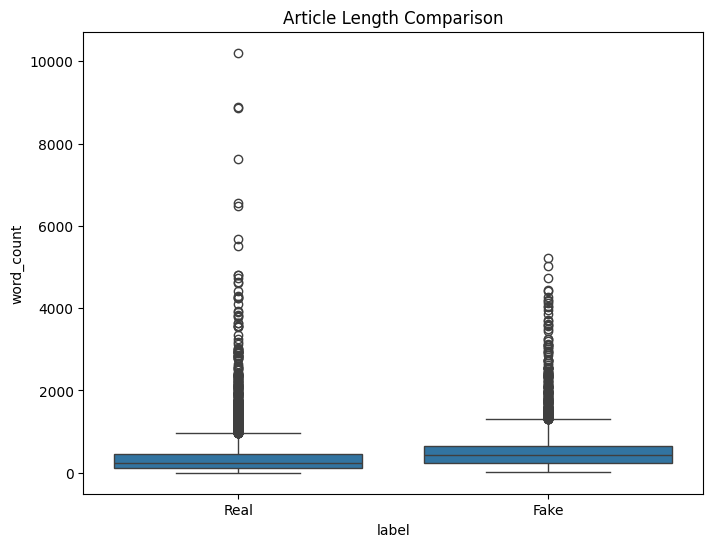

In [57]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="label",
    y="word_count",
    data=df
)

plt.xticks(
    [0,1],
    ["Real","Fake"]
)

plt.title("Article Length Comparison")

plt.show()

label
0    362.318081
1    490.283552
Name: word_count, dtype: float64


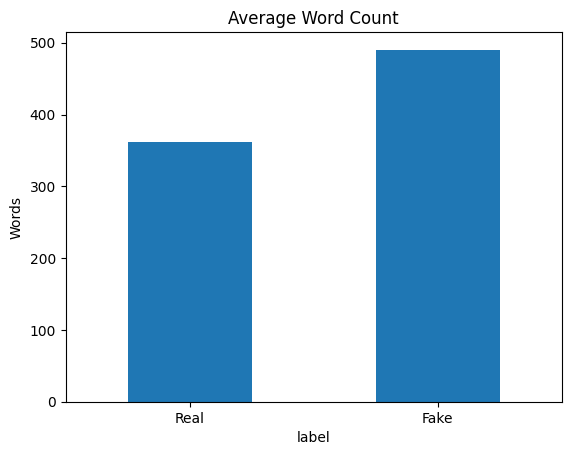

In [58]:
avg_words = df.groupby("label")["word_count"].mean()

print(avg_words)

avg_words.plot(kind="bar")

plt.title("Average Word Count")
plt.ylabel("Words")

plt.xticks(
    [0,1],
    ["Real","Fake"],
    rotation=0
)

plt.show()

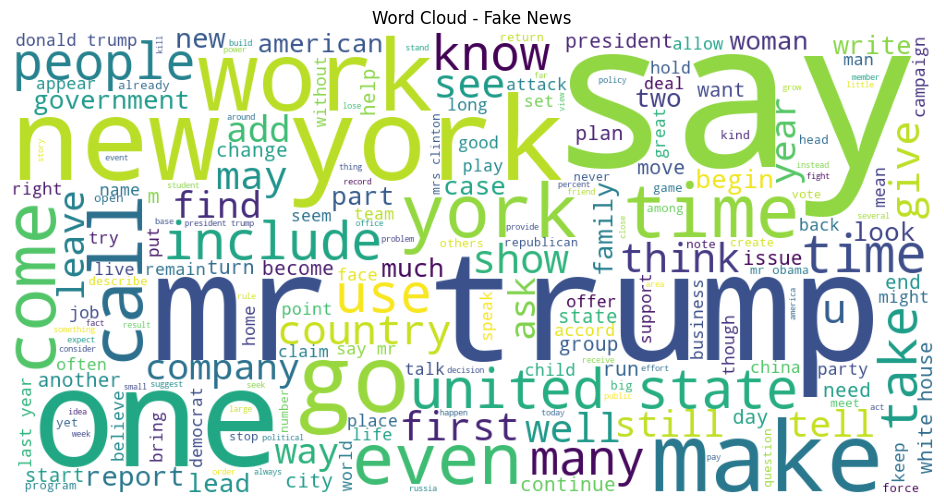

In [59]:
fake_text = " ".join(
    df[df["label"] == 1]["text"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(fake_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud - Fake News")

plt.show()

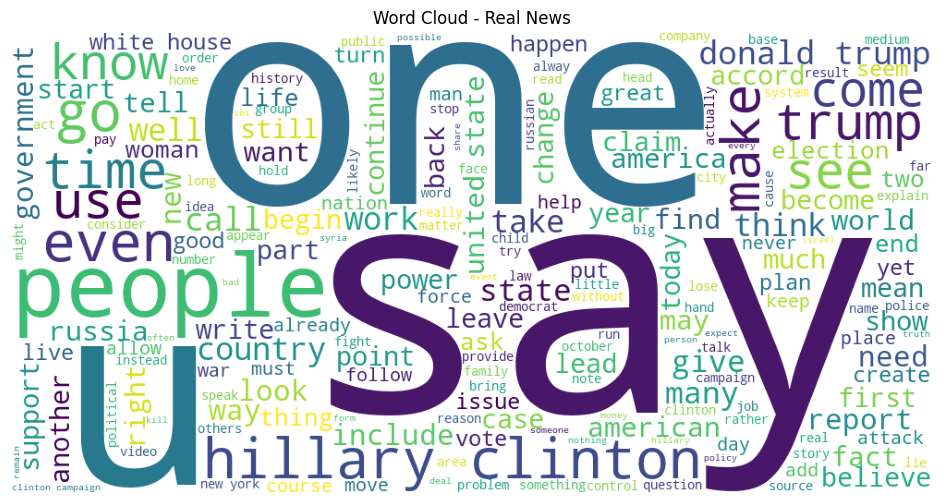

In [60]:
real_text = " ".join(
    df[df["label"] == 0]["text"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(real_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud - Real News")

plt.show()

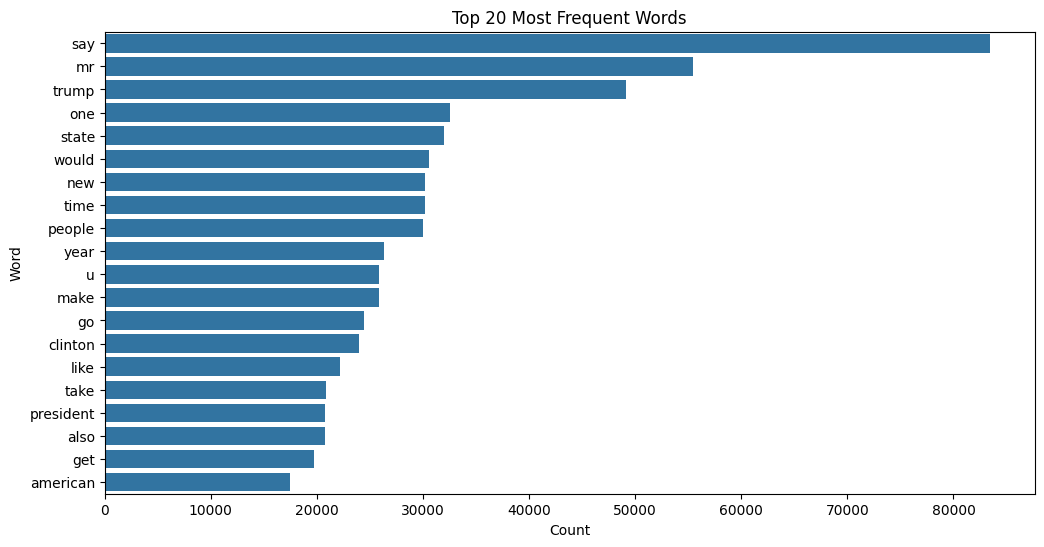

In [61]:
from collections import Counter

all_words = " ".join(df["text"]).split()

counter = Counter(all_words)

top_words = counter.most_common(20)

top_df = pd.DataFrame(
    top_words,
    columns=["Word","Count"]
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_df,
    x="Count",
    y="Word"
)

plt.title("Top 20 Most Frequent Words")

plt.show()

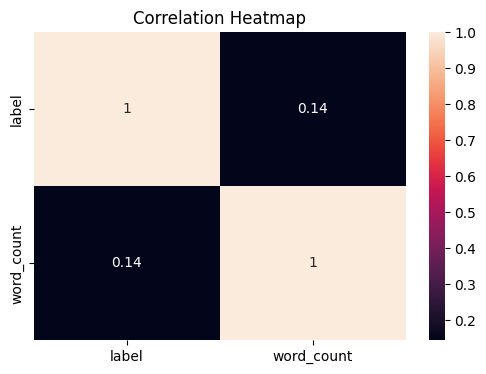

In [62]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[["label","word_count"]].corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [63]:
import pandas as pd
import numpy as np
import pickle
import warnings

warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

In [64]:
print("=" * 60)
print("  PHASE 4 — MODEL TRAINING & EVALUATION")
print("=" * 60)

df = pd.read_csv("preprocessed_news.csv")

print(f"\n✅ Dataset Loaded")
print(f"📦 Shape : {df.shape}")

  PHASE 4 — MODEL TRAINING & EVALUATION

✅ Dataset Loaded
📦 Shape : (16475, 8)


In [65]:
print("\n" + "─" * 60)
print("STEP 1 — FEATURE PREPARATION")
print("─" * 60)

X_text = df["processed_text"]
y = df["label"]

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(X_text)

print("✅ TF-IDF Features Ready")
print("Feature Matrix Shape :", X.shape)


────────────────────────────────────────────────────────────
STEP 1 — FEATURE PREPARATION
────────────────────────────────────────────────────────────
✅ TF-IDF Features Ready
Feature Matrix Shape : (16475, 5000)


In [66]:
print("\n" + "─" * 60)
print("STEP 2 — TRAIN TEST SPLIT")
print("─" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Samples : {X_train.shape[0]:,}")
print(f"Testing Samples  : {X_test.shape[0]:,}")


────────────────────────────────────────────────────────────
STEP 2 — TRAIN TEST SPLIT
────────────────────────────────────────────────────────────
Training Samples : 13,180
Testing Samples  : 3,295


In [73]:
def evaluate_model(name, model):

    print("\n" + "=" * 60)
    print(f"MODEL : {name}")
    print("=" * 60)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predictions))

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

In [74]:
print("\n" + "─" * 60)
print("STEP 3 — LOGISTIC REGRESSION")
print("─" * 60)

lr_model = LogisticRegression(max_iter=1000)

lr_result = evaluate_model(
    "Logistic Regression",
    lr_model
)


────────────────────────────────────────────────────────────
STEP 3 — LOGISTIC REGRESSION
────────────────────────────────────────────────────────────

MODEL : Logistic Regression
Accuracy  : 0.9508
Precision : 0.9552
Recall    : 0.9471
F1 Score  : 0.9511

Confusion Matrix:
[[1556   74]
 [  88 1577]]


In [75]:
print("\n" + "─" * 60)
print("STEP 4 — MULTINOMIAL NAIVE BAYES")
print("─" * 60)

nb_model = MultinomialNB()

nb_result = evaluate_model(
    "Multinomial Naive Bayes",
    nb_model
)


────────────────────────────────────────────────────────────
STEP 4 — MULTINOMIAL NAIVE BAYES
────────────────────────────────────────────────────────────

MODEL : Multinomial Naive Bayes
Accuracy  : 0.8947
Precision : 0.8740
Recall    : 0.9249
F1 Score  : 0.8987

Confusion Matrix:
[[1408  222]
 [ 125 1540]]


In [76]:
print("\n" + "─" * 60)
print("STEP 5 — RANDOM FOREST")
print("─" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_result = evaluate_model(
    "Random Forest",
    rf_model
)


────────────────────────────────────────────────────────────
STEP 5 — RANDOM FOREST
────────────────────────────────────────────────────────────

MODEL : Random Forest
Accuracy  : 0.9663
Precision : 0.9744
Recall    : 0.9586
F1 Score  : 0.9664

Confusion Matrix:
[[1588   42]
 [  69 1596]]


In [77]:
print("\n" + "─" * 60)
print("STEP 6 — DECISION TREE")
print("─" * 60)

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=20
)

dt_result = evaluate_model(
    "Decision Tree",
    dt_model
)


────────────────────────────────────────────────────────────
STEP 6 — DECISION TREE
────────────────────────────────────────────────────────────

MODEL : Decision Tree
Accuracy  : 0.9563
Precision : 0.9623
Recall    : 0.9508
F1 Score  : 0.9565

Confusion Matrix:
[[1568   62]
 [  82 1583]]


In [78]:
print("\n" + "─" * 60)
print("STEP 7 — SUPPORT VECTOR MACHINE")
print("─" * 60)

svm_model = LinearSVC(
    random_state=42
)

svm_result = evaluate_model(
    "Support Vector Machine",
    svm_model
)


────────────────────────────────────────────────────────────
STEP 7 — SUPPORT VECTOR MACHINE
────────────────────────────────────────────────────────────

MODEL : Support Vector Machine
Accuracy  : 0.9621
Precision : 0.9672
Recall    : 0.9574
F1 Score  : 0.9623

Confusion Matrix:
[[1576   54]
 [  71 1594]]


In [79]:
results_df = pd.DataFrame([
    lr_result,
    nb_result,
    rf_result,
    dt_result,
    svm_result
])

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

                     Model  Accuracy  Precision    Recall        F1
2            Random Forest  0.966313   0.974359  0.958559  0.966394
4   Support Vector Machine  0.962064   0.967233  0.957357  0.962270
3            Decision Tree  0.956297   0.962310  0.950751  0.956495
0      Logistic Regression  0.950835   0.955179  0.947147  0.951146
1  Multinomial Naive Bayes  0.894689   0.874007  0.924925  0.898745


In [83]:
models = {
    "Logistic Regression": lr_model,
    "Multinomial Naive Bayes": nb_model,
    "Random Forest": rf_model,
    "Decision Tree": dt_model,
    "Support Vector Machine": svm_model
}

best_model_name = best_model_row["Model"]
best_model = models[best_model_name]

with open("best_fake_news_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print(f"\n💾 Saved Best Model: {best_model_name}")


💾 Saved Best Model: Random Forest


In [84]:
print("\n" + "=" * 60)
print("  PHASE 4 COMPLETE — SUMMARY")
print("=" * 60)

print(f"Total Samples : {len(df):,}")
print(f"Train Samples : {len(y_train):,}")
print(f"Test Samples  : {len(y_test):,}")

print("\n✅ Models Trained:")
print("   • Logistic Regression")
print("   • Multinomial Naive Bayes")
print("   • Random Forest")

print("\n✅ Evaluation Complete")
print("\n➡️ Ready for Phase 5")

print("=" * 60)


  PHASE 4 COMPLETE — SUMMARY
Total Samples : 16,475
Train Samples : 13,180
Test Samples  : 3,295

✅ Models Trained:
   • Logistic Regression
   • Multinomial Naive Bayes
   • Random Forest

✅ Evaluation Complete

➡️ Ready for Phase 5


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings("ignore")
 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
 
print("=" * 65)
print("  PHASE 5 — MODEL EVALUATION")
print("=" * 65)

  PHASE 5 — MODEL EVALUATION


In [3]:
df = pd.read_csv("cleaned_news.csv")
df.dropna(subset=["text", "label"], inplace=True)
print(f"\n✅  Loaded cleaned_news.csv — {len(df):,} articles")
 
X = df["text"]
y = df["label"]


✅  Loaded cleaned_news.csv — 16,475 articles


In [5]:
print("\n▶ Fitting TF-IDF Vectorizer (max_features=5000)...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")
X_tfidf = tfidf.fit_transform(X)
print(f"✅  TF-IDF matrix shape: {X_tfidf.shape}")


▶ Fitting TF-IDF Vectorizer (max_features=5000)...
✅  TF-IDF matrix shape: (16475, 5000)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)
print(f"✅  Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

✅  Train: 13,180  |  Test: 3,295


In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes":         MultinomialNB(),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM":                 LinearSVC(random_state=42, max_iter=2000),
}

In [8]:
print("\n" + "─" * 65)
print("TRAINING & EVALUATING ALL 5 MODELS")
print("─" * 65)
 
results = {}
trained_models = {}
 
for name, model in models.items():
    print(f"\n▶ {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
 
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)
 
    results[name] = {
        "Accuracy":  round(acc  * 100, 2),
        "Precision": round(prec * 100, 2),
        "Recall":    round(rec  * 100, 2),
        "F1 Score":  round(f1   * 100, 2),
        "CM":        cm,
        "y_pred":    y_pred,
    }
    trained_models[name] = model
 
    print(f"   Accuracy : {acc*100:.2f}%")
    print(f"   Precision: {prec*100:.2f}%")
    print(f"   Recall   : {rec*100:.2f}%")
    print(f"   F1 Score : {f1*100:.2f}%")


─────────────────────────────────────────────────────────────────
TRAINING & EVALUATING ALL 5 MODELS
─────────────────────────────────────────────────────────────────

▶ Logistic Regression...
   Accuracy : 94.96%
   Precision: 95.29%
   Recall   : 94.71%
   F1 Score : 95.00%

▶ Naive Bayes...
   Accuracy : 89.17%
   Precision: 86.82%
   Recall   : 92.61%
   F1 Score : 89.63%

▶ Decision Tree...
   Accuracy : 94.45%
   Precision: 94.42%
   Recall   : 94.59%
   F1 Score : 94.51%

▶ Random Forest...
   Accuracy : 96.69%
   Precision: 97.32%
   Recall   : 96.10%
   F1 Score : 96.71%

▶ SVM...
   Accuracy : 95.81%
   Precision: 96.02%
   Recall   : 95.68%
   F1 Score : 95.85%


In [9]:
print("\n" + "=" * 65)
print("  MODEL COMPARISON TABLE")
print("=" * 65)
metrics_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k != "CM" and k != "y_pred"}
    for name, vals in results.items()
}).T
metrics_df.index.name = "Model"
print(metrics_df.to_string())


  MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression     94.96      95.29   94.71     95.00
Naive Bayes             89.17      86.82   92.61     89.63
Decision Tree           94.45      94.42   94.59     94.51
Random Forest           96.69      97.32   96.10     96.71
SVM                     95.81      96.02   95.68     95.85


In [10]:
best_name = metrics_df["F1 Score"].idxmax()
best_model = trained_models[best_name]
print(f"\n🏆  Best Model: {best_name}  (F1 = {metrics_df.loc[best_name,'F1 Score']}%)")


🏆  Best Model: Random Forest  (F1 = 96.71%)


In [11]:
print(f"\n{'─'*65}")
print(f"CLASSIFICATION REPORT — {best_name}")
print(f"{'─'*65}")
best_pred = results[best_name]["y_pred"]
print(classification_report(y_test, best_pred, target_names=["REAL", "FAKE"]))


─────────────────────────────────────────────────────────────────
CLASSIFICATION REPORT — Random Forest
─────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

        REAL       0.96      0.97      0.97      1630
        FAKE       0.97      0.96      0.97      1665

    accuracy                           0.97      3295
   macro avg       0.97      0.97      0.97      3295
weighted avg       0.97      0.97      0.97      3295



In [12]:
os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "models/best_model.pkl")
joblib.dump(tfidf,      "models/tfidf_vectorizer.pkl")
print(f"💾  Saved → models/best_model.pkl")
print(f"💾  Saved → models/tfidf_vectorizer.pkl")

💾  Saved → models/best_model.pkl
💾  Saved → models/tfidf_vectorizer.pkl


In [13]:
sns.set_style("whitegrid")
PALETTE = ["#185FA5", "#E24B4A", "#3B6D11", "#633806", "#3C3489"]
MODEL_NAMES = list(results.keys())
SHORT_NAMES = ["LR", "NB", "DT", "RF", "SVM"]

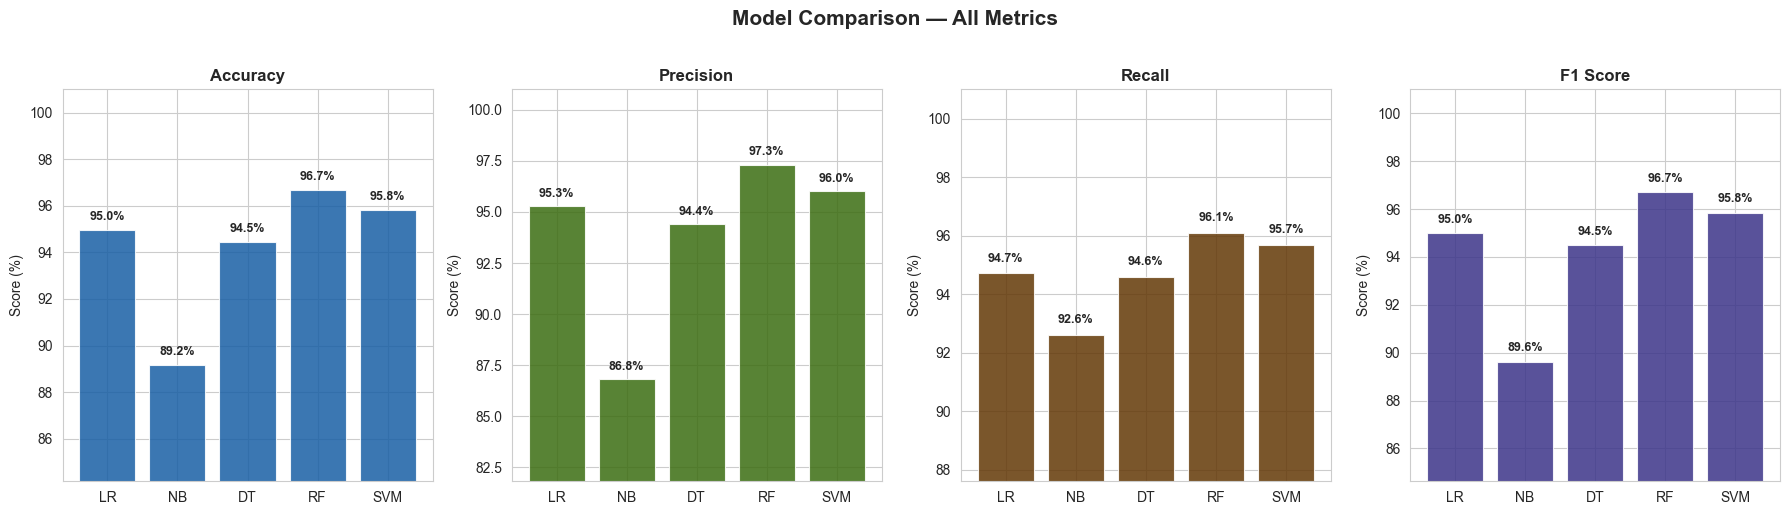

✅  Saved → viz_model_comparison.png


In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Model Comparison — All Metrics", fontsize=15, fontweight="bold", y=1.02)
 
metric_list = ["Accuracy", "Precision", "Recall", "F1 Score"]
colors = ["#185FA5", "#3B6D11", "#633806", "#3C3489"]
 
for ax, metric, color in zip(axes, metric_list, colors):
    values = [results[m][metric] for m in MODEL_NAMES]
    bars = ax.bar(SHORT_NAMES, values, color=color, alpha=0.85, edgecolor="white", linewidth=0.8)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylim(min(values) - 5, 101)
    ax.set_ylabel("Score (%)")
    ax.tick_params(axis="x", labelsize=10)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
 
plt.tight_layout()
plt.savefig("viz_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Saved → viz_model_comparison.png")

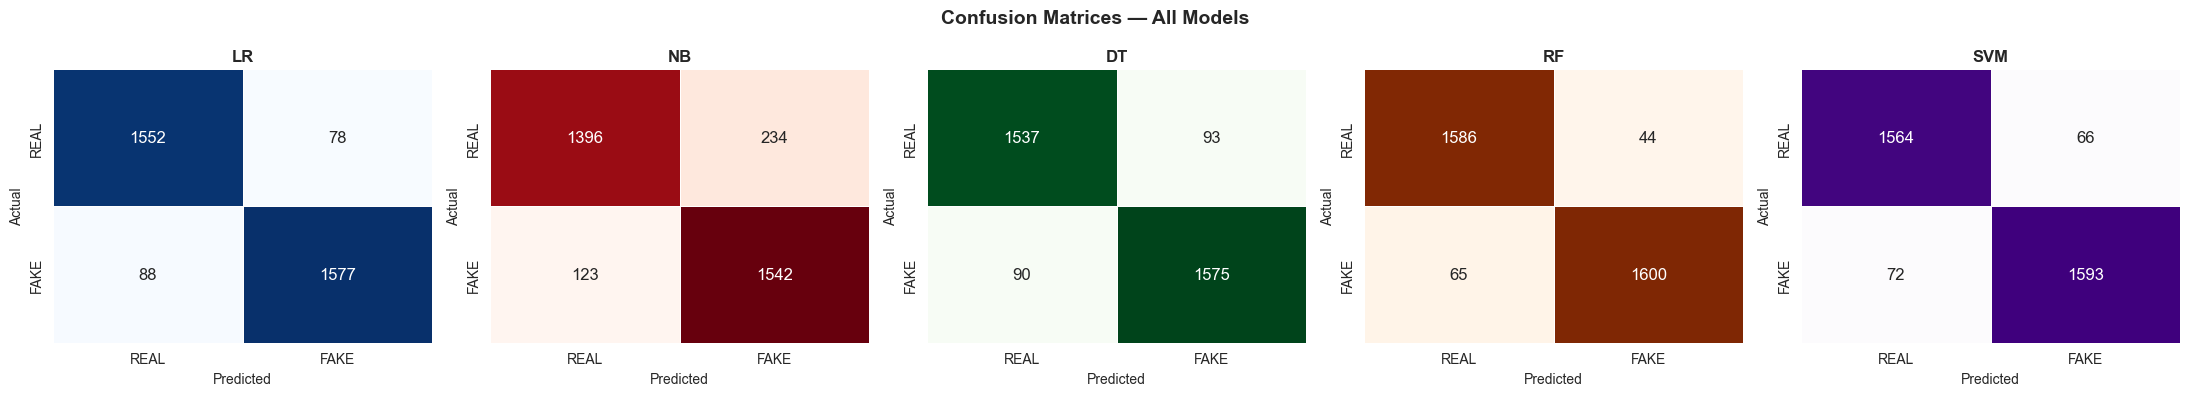

✅  Saved → viz_confusion_matrices.png


In [15]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")
 
cmaps = ["Blues", "Reds", "Greens", "Oranges", "Purples"]
for ax, (name, short), cmap in zip(axes, zip(MODEL_NAMES, SHORT_NAMES), cmaps):
    cm = results[name]["CM"]
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=["REAL", "FAKE"],
                yticklabels=["REAL", "FAKE"],
                linewidths=0.5, cbar=False, annot_kws={"size": 12})
    ax.set_title(short, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
 
plt.tight_layout()
plt.savefig("viz_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Saved → viz_confusion_matrices.png")

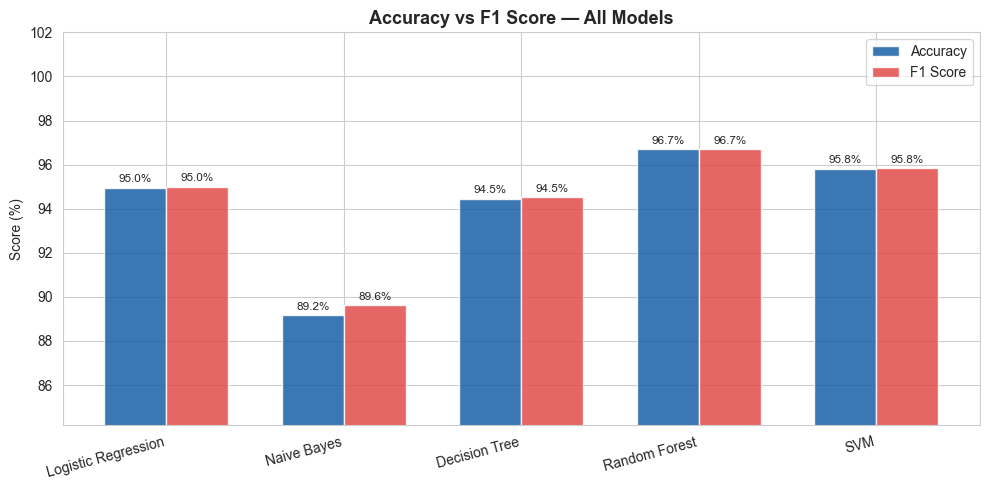

✅  Saved → viz_accuracy_f1_comparison.png


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
f1_vals = [results[m]["F1 Score"] for m in MODEL_NAMES]
acc_vals = [results[m]["Accuracy"] for m in MODEL_NAMES]
x = np.arange(len(MODEL_NAMES))
width = 0.35
 
bars1 = ax.bar(x - width/2, acc_vals, width, label="Accuracy", color="#185FA5", alpha=0.85)
bars2 = ax.bar(x + width/2, f1_vals,  width, label="F1 Score",  color="#E24B4A", alpha=0.85)
 
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8.5)
 
ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES, rotation=15, ha="right")
ax.set_ylim(min(acc_vals + f1_vals) - 5, 102)
ax.set_ylabel("Score (%)")
ax.set_title("Accuracy vs F1 Score — All Models", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("viz_accuracy_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Saved → viz_accuracy_f1_comparison.png")

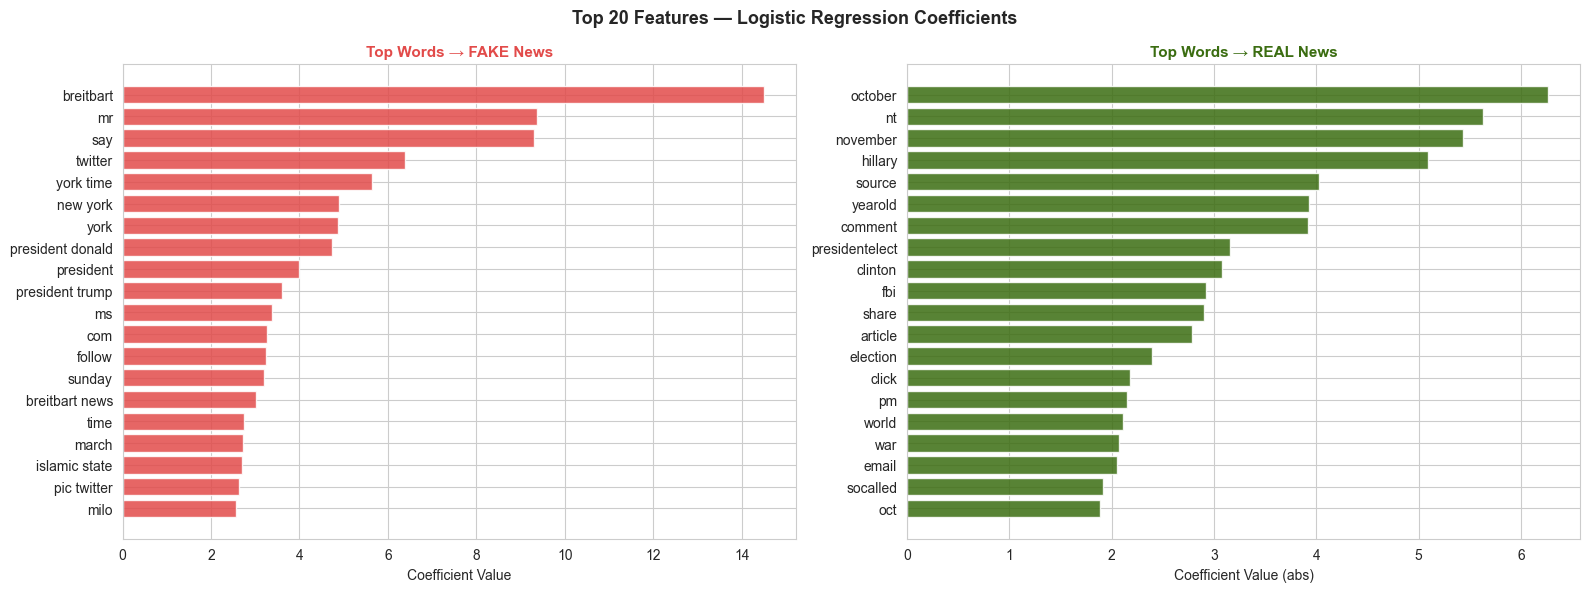

✅  Saved → viz_feature_importance.png


In [17]:
# Uses Logistic Regression coefficients (most interpretable)
lr_model = trained_models["Logistic Regression"]
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr_model.coef_[0]
 
top_fake_idx = np.argsort(coefs)[-20:][::-1]
top_real_idx = np.argsort(coefs)[:20]
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top 20 Features — Logistic Regression Coefficients", fontsize=13, fontweight="bold")
 
# FAKE side
axes[0].barh(feature_names[top_fake_idx], coefs[top_fake_idx],
             color="#E24B4A", alpha=0.85, edgecolor="white")
axes[0].set_title("Top Words → FAKE News", fontsize=11, fontweight="bold", color="#E24B4A")
axes[0].set_xlabel("Coefficient Value")
axes[0].invert_yaxis()
 
# REAL side
axes[1].barh(feature_names[top_real_idx], np.abs(coefs[top_real_idx]),
             color="#3B6D11", alpha=0.85, edgecolor="white")
axes[1].set_title("Top Words → REAL News", fontsize=11, fontweight="bold", color="#3B6D11")
axes[1].set_xlabel("Coefficient Value (abs)")
axes[1].invert_yaxis()
 
plt.tight_layout()
plt.savefig("viz_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Saved → viz_feature_importance.png")

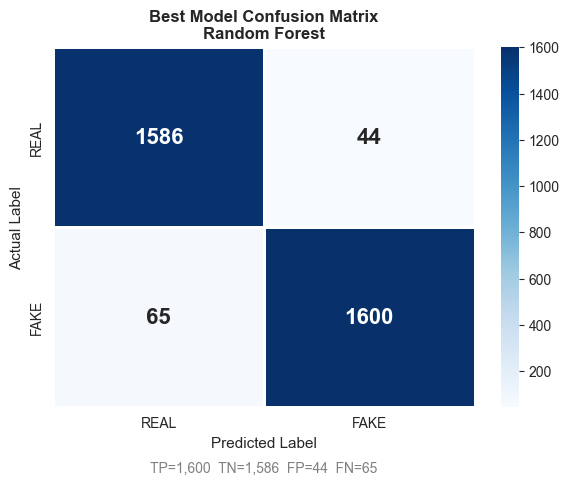

✅  Saved → viz_best_model_cm.png


In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_best = results[best_name]["CM"]
tn, fp, fn, tp = cm_best.ravel()
 
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["REAL", "FAKE"],
            yticklabels=["REAL", "FAKE"],
            linewidths=1, cbar=True, annot_kws={"size": 16, "weight": "bold"})
ax.set_title(f"Best Model Confusion Matrix\n{best_name}", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("Actual Label", fontsize=11)
 
# Annotations
ax.text(0.5, -0.18, f"TP={tp:,}  TN={tn:,}  FP={fp:,}  FN={fn:,}",
        ha="center", transform=ax.transAxes, fontsize=10, color="gray")
 
plt.tight_layout()
plt.savefig("viz_best_model_cm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Saved → viz_best_model_cm.png")

In [19]:
print("\n" + "─" * 65)
print("QUICK PREDICTION TEST — 2 UNSEEN ARTICLES")
print("─" * 65)
 
test_articles = [
    "Scientists confirm climate change is accelerating based on decades of satellite data and peer-reviewed research published in Nature journal.",
    "SHOCKING: Government hiding alien contact since 1947! Leaked documents reveal deep state conspiracy. Share before they delete this!"
]
 
for article in test_articles:
    vec  = tfidf.transform([article])
    pred = best_model.predict(vec)[0]
    label = "🔴 FAKE" if pred == 1 else "🟢 REAL"
    print(f"\n  Article : {article[:80]}...")
    print(f"  Result  : {label}")


─────────────────────────────────────────────────────────────────
QUICK PREDICTION TEST — 2 UNSEEN ARTICLES
─────────────────────────────────────────────────────────────────

  Article : Scientists confirm climate change is accelerating based on decades of satellite ...
  Result  : 🟢 REAL

  Article : SHOCKING: Government hiding alien contact since 1947! Leaked documents reveal de...
  Result  : 🟢 REAL


In [20]:
print("\n" + "=" * 65)
print("  PHASE 5 COMPLETE — FINAL SUMMARY")
print("=" * 65)
print(metrics_df.to_string())
print(f"\n🏆  Best Model : {best_name}")
print(f"    F1 Score   : {metrics_df.loc[best_name, 'F1 Score']}%")
print(f"    Accuracy   : {metrics_df.loc[best_name, 'Accuracy']}%")
print(f"\n📁  Saved files:")
print(f"    models/best_model.pkl")
print(f"    models/tfidf_vectorizer.pkl")
print(f"    viz_model_comparison.png")
print(f"    viz_confusion_matrices.png")
print(f"    viz_accuracy_f1_comparison.png")
print(f"    viz_feature_importance.png")
print(f"    viz_best_model_cm.png")
print(f"\n✅  Ready for Phase 6 — Streamlit Deployment")
print("=" * 65)


  PHASE 5 COMPLETE — FINAL SUMMARY
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression     94.96      95.29   94.71     95.00
Naive Bayes             89.17      86.82   92.61     89.63
Decision Tree           94.45      94.42   94.59     94.51
Random Forest           96.69      97.32   96.10     96.71
SVM                     95.81      96.02   95.68     95.85

🏆  Best Model : Random Forest
    F1 Score   : 96.71%
    Accuracy   : 96.69%

📁  Saved files:
    models/best_model.pkl
    models/tfidf_vectorizer.pkl
    viz_model_comparison.png
    viz_confusion_matrices.png
    viz_accuracy_f1_comparison.png
    viz_feature_importance.png
    viz_best_model_cm.png

✅  Ready for Phase 6 — Streamlit Deployment
